In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
qc=QuantumCircuit(1)
qc.x(0)
qc.measure_all()

In [ ]:
simulator=Aer.get_backend('qasm_simulator')
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts(qc)
print(counts)

{'1': 1024}


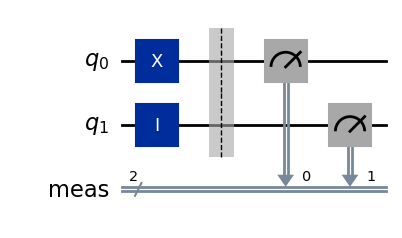

In [ ]:
#  10 => |10>
qc=QuantumCircuit(2)
qc.x(0)
qc.id(1)
qc.measure_all()
qc.draw('mpl')

In [ ]:
simulator=Aer.get_backend('qasm_simulator')
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts(qc)
print(counts)

{'01': 1024}


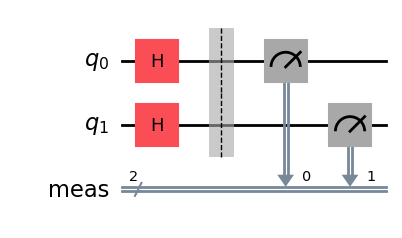

In [ ]:
qc=QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.measure_all()
qc.draw('mpl')

In [ ]:
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt
simulator=Aer.get_backend('qasm_simulator')
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts(qc)
print(counts)

{'00': 268, '10': 251, '11': 228, '01': 277}


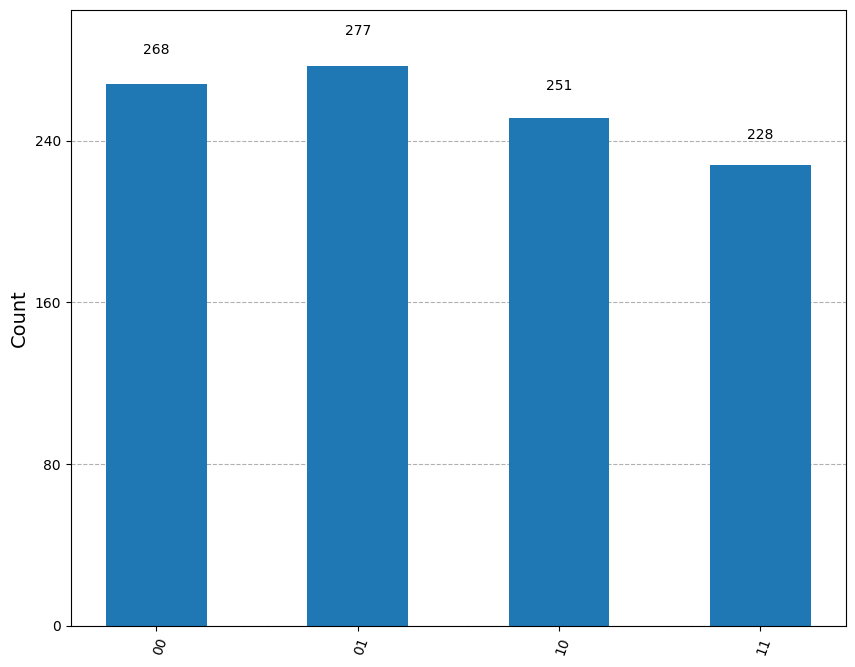

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_histogram(counts, ax=ax)
plt.show()

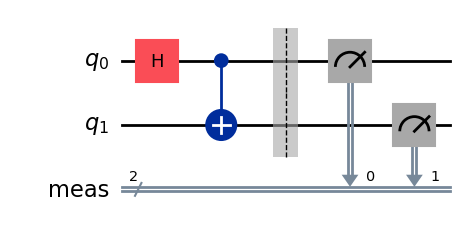

In [ ]:
qc=QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()
qc.draw('mpl')

In [ ]:
simulator=Aer.get_backend('qasm_simulator')
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts(qc)
print(counts)

{'11': 483, '00': 541}


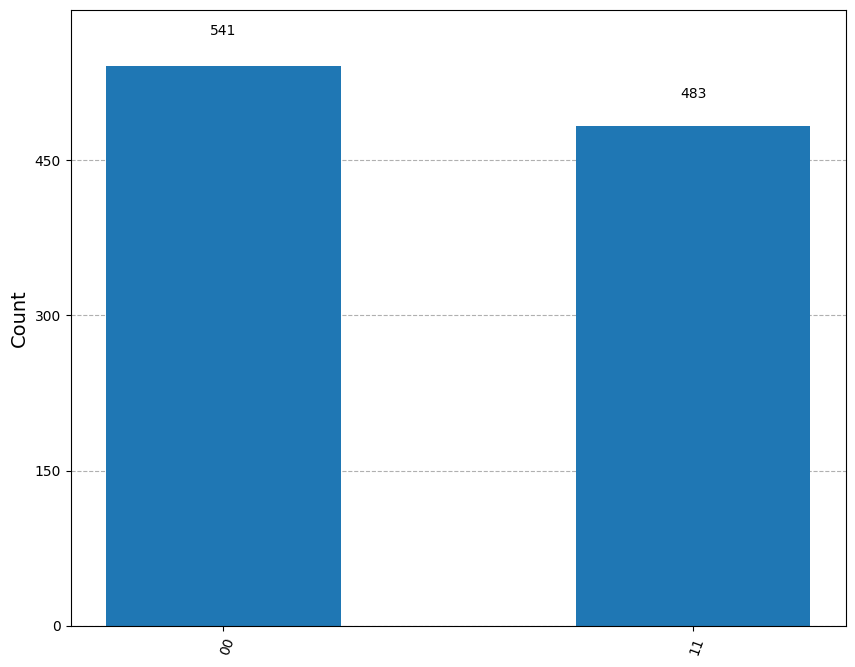

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
plot_histogram(counts,ax=ax)
plt.show()

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [ ]:
def binary_to_qubit(n):
  binary=bin(n)[2:]
  num=len(binary)
  qc=QuantumCircuit(num)
  rev=binary[::-1]
  for i in range(num):
    if rev[i]=='1':
      qc.x(i)
  return qc,binary

decimal num:  5
binary num:  101
qubit format: | 101 >


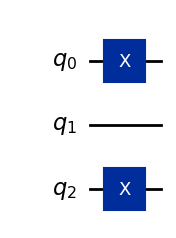

In [ ]:
qc,binary=binary_to_qubit(5)
print("decimal num: ",5)
print("binary num: ",binary)
print("qubit format: |",binary,">")
qc.draw('mpl')

In [ ]:
state=Statevector.from_instruction(qc)
print(state)

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


In [ ]:
from qiskit.visualization import plot_bloch_multivector
import numpy as np

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


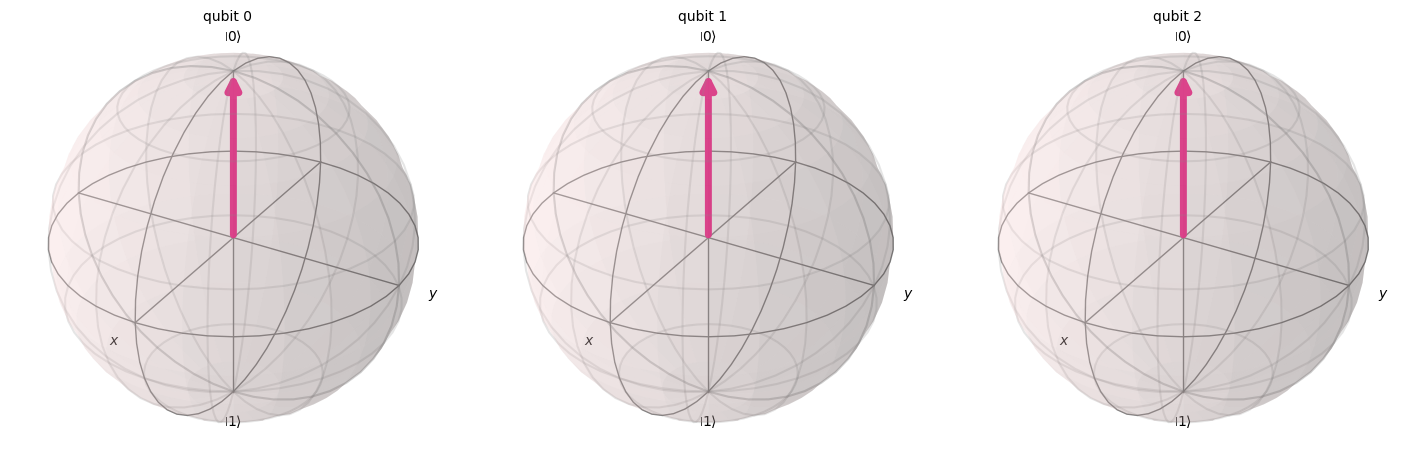

Statevector([2.29584502e-49+0.j, 3.74939946e-33+0.j, 3.74939946e-33+0.j,
             6.12323400e-17+0.j, 3.74939946e-33+0.j, 6.12323400e-17+0.j,
             6.12323400e-17+0.j, 1.00000000e+00+0.j],
            dims=(2, 2, 2))


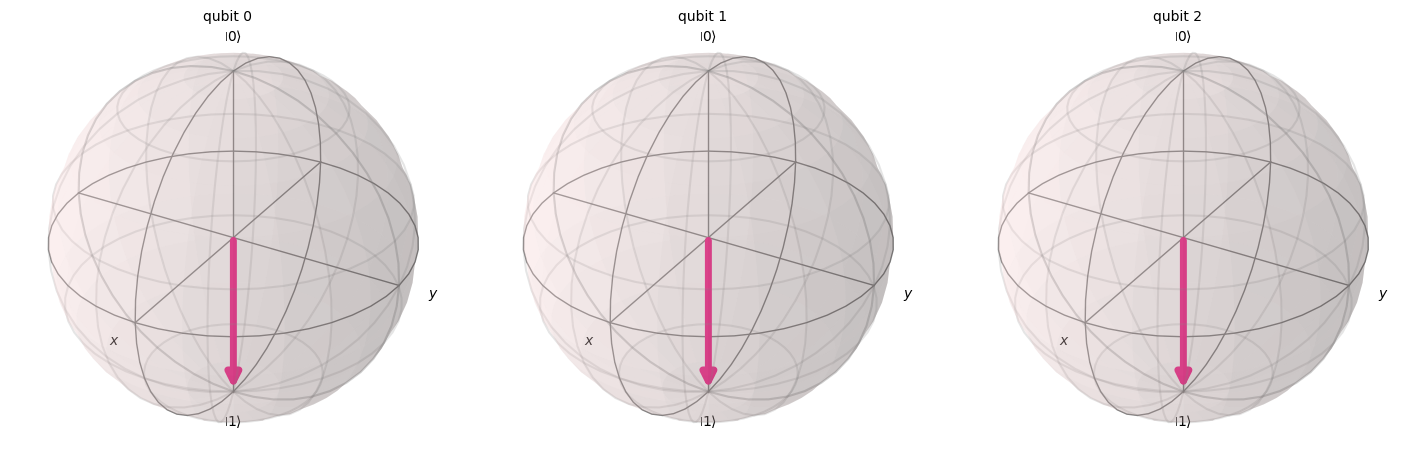

In [ ]:
data=np.array([1,2,3])
nq=len(data)
qc=QuantumCircuit(nq)
sv=Statevector.from_instruction(qc)
print(sv)
display(plot_bloch_multivector(sv))
qc.ry(np.pi,0)
qc.ry(np.pi,1)
qc.ry(np.pi,2)
sv=Statevector.from_instruction(qc)
print(sv)
display(plot_bloch_multivector(sv))


In [ ]:
from qiskit import transpile
from qiskit.visualization import plot_bloch_multivector

{'1': 496, '0': 528}


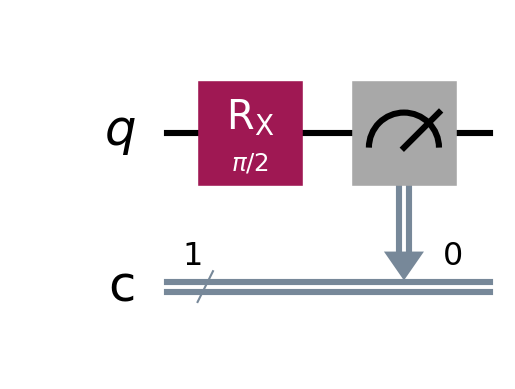

In [ ]:
qc=QuantumCircuit(1,1)
qc.rx(np.pi/2,0)
qc.measure(0,0)
simulator=Aer.get_backend('aer_simulator')
qc=transpile(qc,simulator)
result=simulator.run(qc,shots=1024).result()
counts=result.get_counts()
print(counts)
qc.draw('mpl',ax=plt.gca())
plt.show()


Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


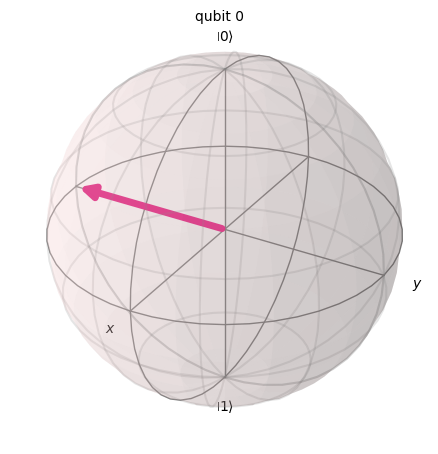

In [ ]:
qc=QuantumCircuit(1)
qc.rx(np.pi/2,0)
sv=Statevector.from_instruction(qc)
print(sv)
qc.draw('mpl')
plot_bloch_multivector(qc)

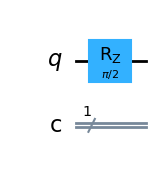

In [ ]:
qc=QuantumCircuit(1,1)
qc.rz(np.pi/2,0)
qc.draw('mpl')


Statevector([0.70710678-0.70710678j, 0.        +0.j        ],
            dims=(2,))


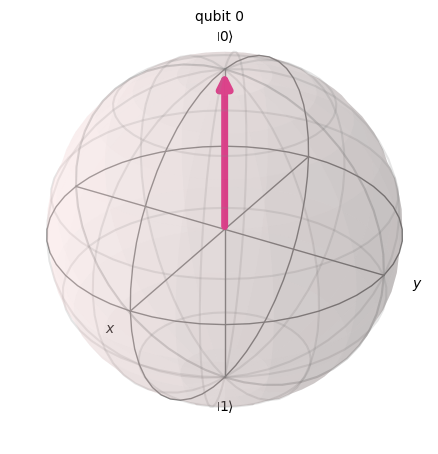

In [ ]:
sv=Statevector.from_instruction(qc)
print(sv)
display(plot_bloch_multivector(sv))


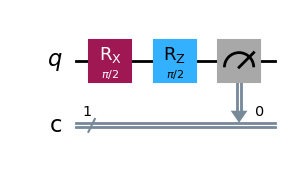

In [ ]:
qc=QuantumCircuit(1,1)
qc.rx(np.pi/2,0)
qc.rz(np.pi/2,0)
qc.measure(0,0)
qc.draw('mpl')

In [ ]:
simulator=Aer.get_backend('qasm_simulator')
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts(qc)
print(counts)

{'1': 505, '0': 519}


statevector after rx : Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


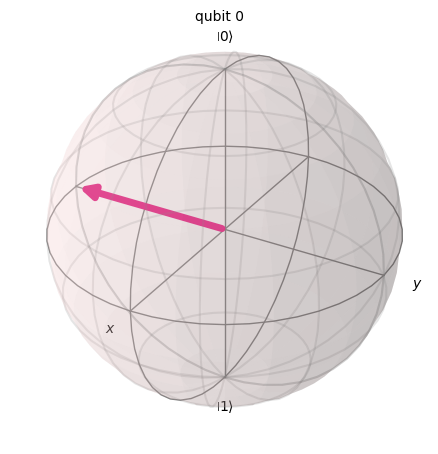

statevector after rz :  Statevector([0.5-0.5j, 0.5-0.5j],
            dims=(2,))


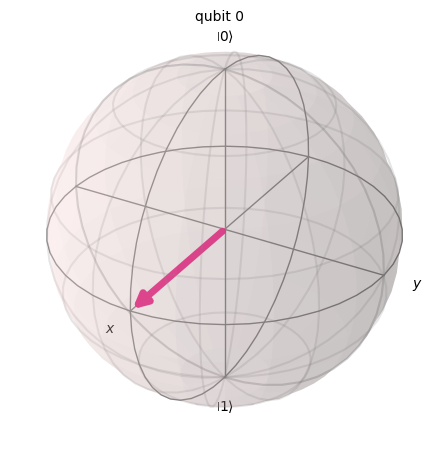

In [ ]:
qcs = QuantumCircuit(1)
qcs.rx(np.pi/2, 0)
sv = Statevector.from_instruction(qcs)
print("statevector after rx :",sv)
display(plot_bloch_multivector(sv))
qcs.rz(np.pi/2, 0)
sv = Statevector.from_instruction(qcs)
print("statevector after rz : ",sv)
display(plot_bloch_multivector(sv))

DATA ENCODING ON VECTOR

In [ ]:
import numpy as np
data=np.array([0.2,1.1,2.4])
n=len(data)

In [ ]:
from qiskit import QuantumCircuit
qc=QuantumCircuit(n)
for i,value in enumerate(data):
  qc.ry(value,i)

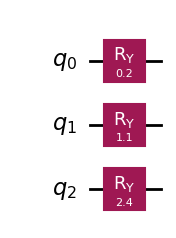

In [ ]:
qc.draw('mpl')

In [ ]:
sv=Statevector.from_instruction(qc)
print(sv)

Statevector([0.30737556+0.j, 0.03084043+0.j, 0.18845356+0.j,
             0.01890843+0.j, 0.79061656+0.j, 0.07932625+0.j,
             0.48473113+0.j, 0.04863534+0.j],
            dims=(2, 2, 2))


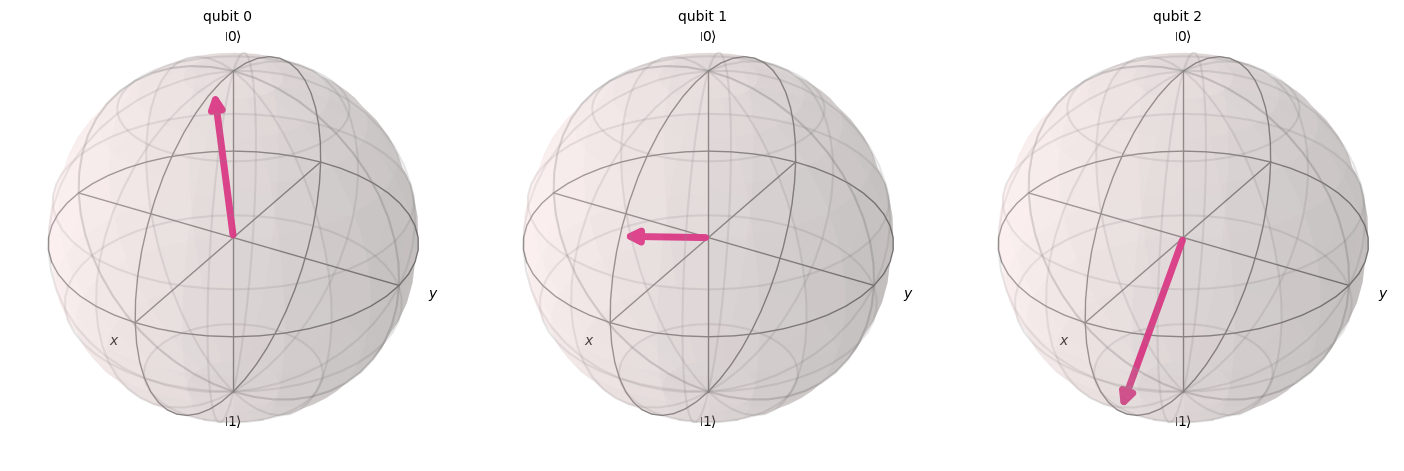

In [ ]:
display(plot_bloch_multivector(sv))

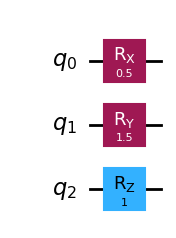

In [ ]:
data=np.array([0.5,1.5,1.0])
n=len(data)
qc=QuantumCircuit(n)
qc.rx(data[0],0)
qc.ry(data[1],1)
qc.rz(data[2],2)
qc.draw('mpl')

Statevector([ 0.62215552-0.33988511j, -0.08678692-0.15886239j,
              0.57959788-0.31663576j, -0.08085038-0.14799564j,
              0.        +0.j        ,  0.        +0.j        ,
              0.        +0.j        ,  0.        +0.j        ],
            dims=(2, 2, 2))


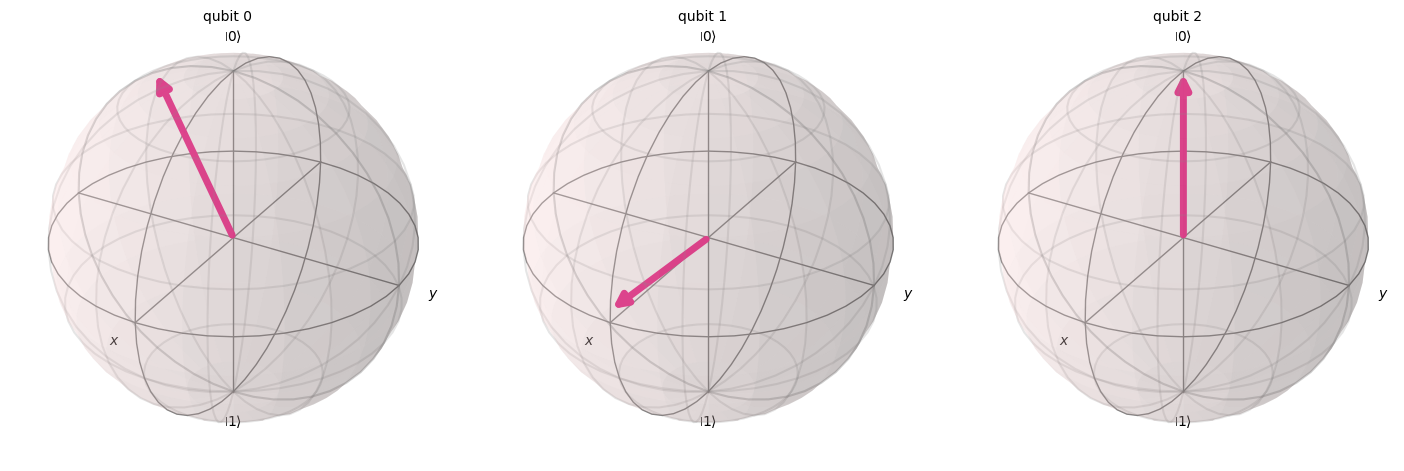

In [ ]:
sv=Statevector.from_instruction(qc)
print(sv)
display(plot_bloch_multivector(sv))